In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
1#first of all we should read the movielens file !1
df=pd.read_csv("M.DE.csv")
df.head()


,movieId,userId,genres,title,tag,timestamp,rating
0,1.0,1,Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995),funny,964982703,4.0
1,2.0,1,Adventure|Children|Fantasy,Jumanji (1995),Highly quotable,964981247,4.0
2,3.0,1,Comedy|Romance,Grumpier Old Men (1995),will ferrell,964982224,4.0
3,4.0,1,Comedy|Drama|Romance,Waiting to Exhale (1995),Boxing story,964983815,5.0
4,5.0,1,Comedy,Father of the Bride Part II (1995),MMA,964982931,5.0


In [ ]:
#we should check if there any missing values !
df.isnull().sum()

,0
movieId,91094
userId,0
genres,91094
title,91094
tag,97153
timestamp,0
rating,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    9742 non-null    float64
 1   userId     100836 non-null  int64  
 2   genres     9742 non-null    object 
 3   title      9742 non-null    object 
 4   tag        3683 non-null    object 
 5   timestamp  100836 non-null  int64  
 6   rating     100836 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 5.4+ MB


In [ ]:
#Fill missing values
df['genres'] = df['genres'].fillna(df['genres'].mode()[0])
df

,movieId,userId,genres,title,tag,timestamp,rating
0,1.0,1,Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995),funny,964982703,4.0
1,2.0,1,Adventure|Children|Fantasy,Jumanji (1995),Highly quotable,964981247,4.0
2,3.0,1,Comedy|Romance,Grumpier Old Men (1995),will ferrell,964982224,4.0
3,4.0,1,Comedy|Drama|Romance,Waiting to Exhale (1995),Boxing story,964983815,5.0
4,5.0,1,Comedy,Father of the Bride Part II (1995),MMA,964982931,5.0
...,...,...,...,...,...,...,...
100831,NaN,610,Drama,NaN,NaN,1493848402,4.0
100832,NaN,610,Drama,NaN,NaN,1493850091,5.0
100833,NaN,610,Drama,NaN,NaN,1494273047,5.0
100834,NaN,610,Drama,NaN,NaN,1493846352,5.0


In [ ]:
df["movieId"]=df["movieId"].fillna(df["movieId"].mean())


df

,movieId,userId,genres,title,tag,timestamp,rating
0,1.000000,1,Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995),funny,964982703,4.0
1,2.000000,1,Adventure|Children|Fantasy,Jumanji (1995),Highly quotable,964981247,4.0
2,3.000000,1,Comedy|Romance,Grumpier Old Men (1995),will ferrell,964982224,4.0
3,4.000000,1,Comedy|Drama|Romance,Waiting to Exhale (1995),Boxing story,964983815,5.0
4,5.000000,1,Comedy,Father of the Bride Part II (1995),MMA,964982931,5.0
...,...,...,...,...,...,...,...
100831,42200.353623,610,Drama,NaN,NaN,1493848402,4.0
100832,42200.353623,610,Drama,NaN,NaN,1493850091,5.0
100833,42200.353623,610,Drama,NaN,NaN,1494273047,5.0
100834,42200.353623,610,Drama,NaN,NaN,1493846352,5.0


In [ ]:
df['title'] = df['title'].fillna(df['title'].mode()[0])
#We use [0] because mode() returns a Series of possible most-frequent values, and [0] selects one single value so fillna() can replace missing data.


In [ ]:
df['tag'] = df['tag'].fillna(df['tag'].mode()[0])


In [ ]:
#Remove Duplicates
df.drop_duplicates()

,movieId,userId,genres,title,tag,timestamp,rating
0,1.000000,1,Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995),funny,964982703,4.0
1,2.000000,1,Adventure|Children|Fantasy,Jumanji (1995),Highly quotable,964981247,4.0
2,3.000000,1,Comedy|Romance,Grumpier Old Men (1995),will ferrell,964982224,4.0
3,4.000000,1,Comedy|Drama|Romance,Waiting to Exhale (1995),Boxing story,964983815,5.0
4,5.000000,1,Comedy,Father of the Bride Part II (1995),MMA,964982931,5.0
...,...,...,...,...,...,...,...
100831,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,1493848402,4.0
100832,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,1493850091,5.0
100833,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,1494273047,5.0
100834,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,1493846352,5.0


In [ ]:
# this is a simple description !
df.describe()

,movieId,userId,timestamp,rating
count,100836.000000,100836.000000,1.008360e+05,100836.000000
mean,42200.353623,326.127564,1.205946e+09,3.501557
std,16212.045850,182.618491,2.162610e+08,1.042529
min,1.000000,1.000000,8.281246e+08,0.500000
25%,42200.353623,177.000000,1.019124e+09,3.000000
50%,42200.353623,325.000000,1.186087e+09,3.500000
75%,42200.353623,477.000000,1.435994e+09,4.000000
max,193609.000000,610.000000,1.537799e+09,5.000000


In [ ]:
df.isnull().sum() #after our datacleaning there is no missing values !


,0
movieId,0
userId,0
genres,0
title,0
tag,0
timestamp,0
rating,0


In [ ]:
df = df[df['genres'] != '(no genres listed)'] # Remove rows where genre is '(no genres listed)'2

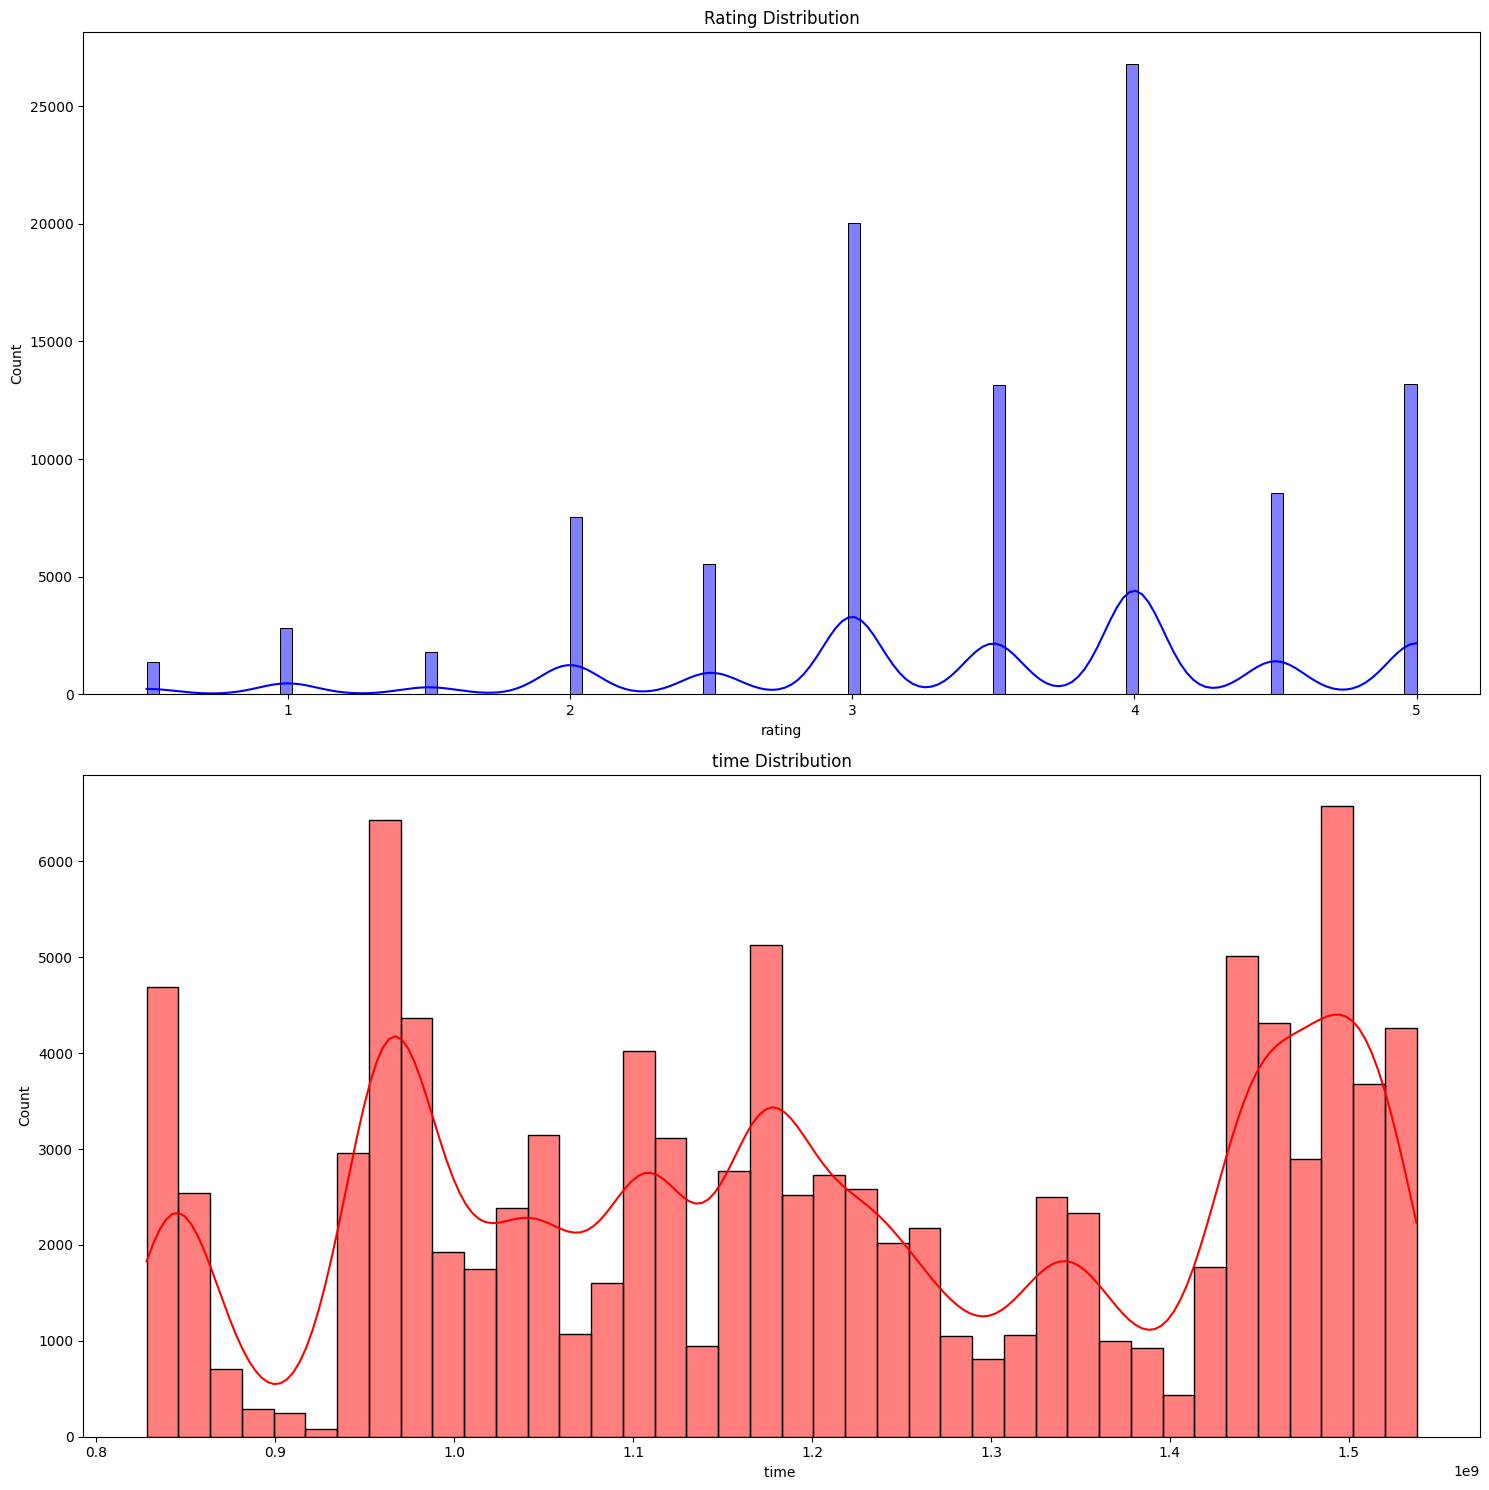

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 15))
sns.histplot(df["rating"],kde=True,color="b",ax=axes[0]) #finding the Distribution of rating
axes[0].set_title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")


sns.histplot(df["timestamp"],kde=True,color="r",ax=axes[1]) # finding the Distribution of timestamp
plt.title("time Distribution")
plt.xlabel("time ")
plt.ylabel("Count")



plt.tight_layout()
plt.show()





In [ ]:
df['genres']=df['genres'].str.split('|')#splits the string in the genres column of the DataFrame into a list
df=df.explode('genres') #Converts element in list in  genres column into a separate row

/tmp/ipython-input-1508385185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['genres']=df['genres'].str.split('|')#splits the string in the genres column of the DataFrame into a list


In [ ]:
gro=df.groupby('genres').agg(
    avg=('rating', 'mean'),
    num=('rating', 'count')
) # grouping the genres to find the avg between rating and rating num
gro

,avg,num
genres,,
Action,3.558807,1828
Adventure,3.573238,1263
Animation,3.655483,611
Children,3.574548,664
Comedy,3.524760,3756
Crime,3.552544,1199
Documentary,3.562500,440
Drama,3.499141,95455
Fantasy,3.621309,779


/tmp/ipython-input-2612547528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gro,y='genres', x='avg',palette="RdBu")# Analyzing into a barplot


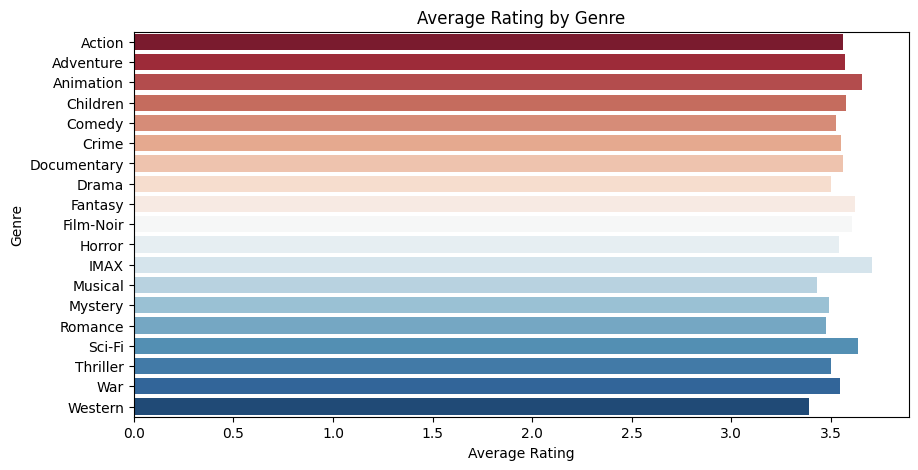

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=gro,y='genres', x='avg',palette="RdBu")# Analyzing into a barplot
plt.title('Average Rating by Genre')
plt.ylabel('Genre')
plt.xlabel('Average Rating')
plt.show()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df

,movieId,userId,genres,title,tag,timestamp,rating
0,1.000000,1,Adventure,Toy Story (1995),funny,2000-07-30 18:45:03,4.0
0,1.000000,1,Animation,Toy Story (1995),funny,2000-07-30 18:45:03,4.0
0,1.000000,1,Children,Toy Story (1995),funny,2000-07-30 18:45:03,4.0
0,1.000000,1,Comedy,Toy Story (1995),funny,2000-07-30 18:45:03,4.0
0,1.000000,1,Fantasy,Toy Story (1995),funny,2000-07-30 18:45:03,4.0
...,...,...,...,...,...,...,...
100831,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,2017-05-03 21:53:22,4.0
100832,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,2017-05-03 22:21:31,5.0
100833,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,2017-05-08 19:50:47,5.0
100834,42200.353623,610,Drama,Confessions of a Dangerous Mind (2002),In Netflix queue,2017-05-03 21:19:12,5.0


In [ ]:
df['year'] = df['timestamp'].dt.year

In [ ]:
df["timestamp"]

,timestamp
0,2000-07-30 18:45:03
0,2000-07-30 18:45:03
0,2000-07-30 18:45:03
0,2000-07-30 18:45:03
0,2000-07-30 18:45:03
...,...
100831,2017-05-03 21:53:22
100832,2017-05-03 22:21:31
100833,2017-05-08 19:50:47
100834,2017-05-03 21:19:12


In [ ]:
avg_year = df.groupby('year')['rating'].mean().reset_index()#grouping time by year and calculating the avg
avg_year

,year,rating
0,1996,3.573455
1,1997,3.709647
2,1998,3.489796
3,1999,3.770111
4,2000,3.406515
5,2001,3.533888
6,2002,3.609845
7,2003,3.512682
8,2004,3.494701
9,2005,3.445638


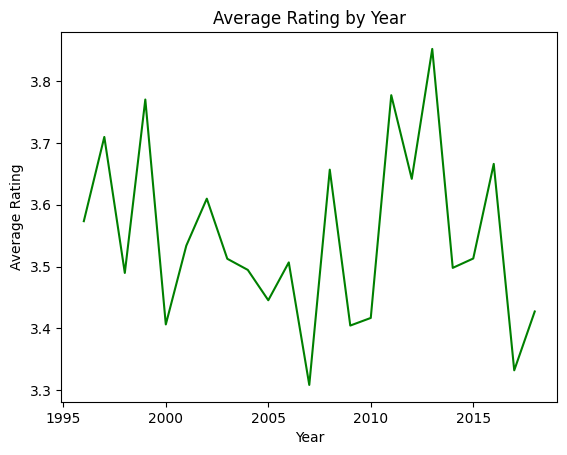

In [ ]:
sns.lineplot(data=avg_year,x="year",y="rating",color="green")
plt.title('Average Rating by Year')
plt.xlabel('Year') #Analyzing avg rating by year
plt.ylabel('Average Rating')
plt.show()

In [ ]:
user_ratings = df.groupby('userId').size().reset_index(name='total_ratings')
user_ratings #grouping total rating per user


,userId,total_ratings
0,1,503
1,2,57
2,3,77
3,4,481
4,5,97
...,...,...
605,606,1115
606,607,187
607,608,831
608,609,37


/tmp/ipython-input-39924069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top,x="genres",y="rating",palette="viridis")


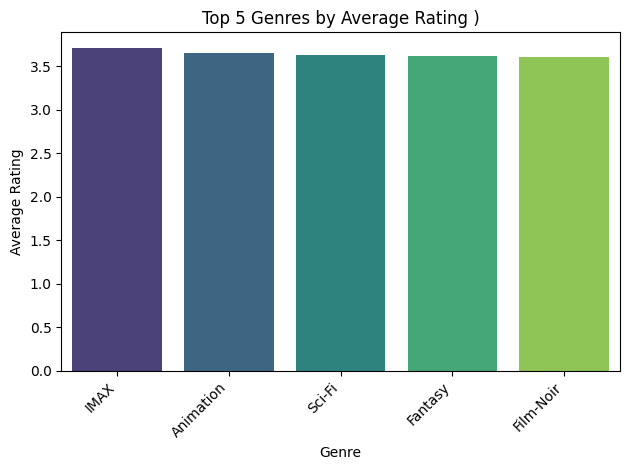

In [ ]:
top=df.groupby("genres")["rating"].mean().reset_index()
top=top.sort_values(by="rating", ascending=False).head(5)
#Analyzing top 5 genres by rating
sns.barplot(data=top,x="genres",y="rating",palette="viridis")
plt.title('Top 5 Genres by Average Rating )')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

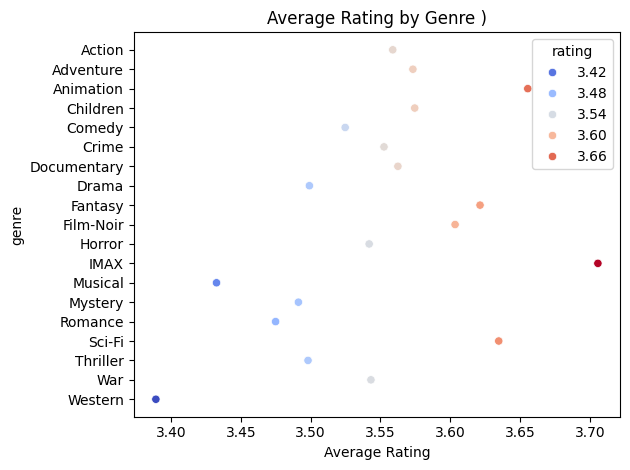

In [ ]:
top_by_genre = gro.reset_index()
top_by_genre = top_by_genre.rename(columns={'avg': 'rating'})
sns.scatterplot(data=top_by_genre, x="rating", hue="rating", y="genres", palette="coolwarm")
plt.title('Average Rating by Genre )')
plt.xlabel('Average Rating') #Analyzing Average Rating by Genre in scatterplot
plt.ylabel('genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()